# LAB5 — Assignment: Counterfactual Explanations with DiCE
## Dataset: Breast Cancer Wisconsin (Diagnostic), UCI ML Repository

| | |
|---|---|
| **Course / Module** | Explainable AI |
| **Topic** | Explainable AI — counterfactual explanations and algorithmic recourse |
| **Dataset** | Breast Cancer Wisconsin (Diagnostic), UCI ID 17 — 569 samples, 30 numeric features |
| **Library** | `dice-ml` (DiCE), `scikit-learn`, `pandas`, `matplotlib` |
| **Total marks** | **100** (+ 10 bonus) |
| **Due** | 17/09/26 |
| **Submission** | this `.ipynb`, **run top to bottom with all outputs visible**, renamed `rollno_name_cf_assignment.ipynb` |

---

### What this assignment is about

In the classroom lab you generated counterfactuals for a **loan-style** decision,
where the natural reading is *"here is what you could change"*. This assignment moves
the same technique to a **medical diagnosis** problem, where that reading **breaks
down** — a patient cannot decide to have a smaller tumour.

Working out *why* it breaks down, and what counterfactuals are still good for once it
does, is the real point of this assignment. Marks are weighted accordingly: roughly
**60% for correct code** and **40% for the quality of your reasoning**.

### Learning outcomes assessed

| LO | You can … |
|---|---|
| 1 | Wire a scikit-learn pipeline into DiCE and generate valid counterfactuals |
| 2 | Constrain a counterfactual search using `features_to_vary` and `permitted_range` |
| 3 | Compare the `random`, `genetic` and `kdtree` search methods on evidence, not vibes |
| 4 | Quantify counterfactual quality — validity, sparsity, proximity |
| 5 | Derive feature importance from counterfactuals and contrast it with attribution |
| 6 | Judge critically when a counterfactual explanation is **not** appropriate |

---

### Rules and how to submit

1. **Answer in this notebook.** Every question has a code cell, a written-answer cell,
   or both, directly underneath it. Add extra cells if you need them — do not delete
   the question cells.
2. **Your notebook must run from a fresh kernel, top to bottom, without errors.**
   Before submitting: *Kernel → Restart & Run All*. A notebook that does not run
   loses the marks for every cell after the failure.
3. **Set `random_state=42` everywhere it is accepted.** Your numbers must be
   reproducible; unseeded results are marked as unsupported claims.
4. **Every plot needs a title, axis labels and units.** An unlabelled plot scores
   zero for that part.
5. **Written answers are marked on reasoning, not length.** Stay inside the stated
   word count. Quote your own numbers — *"sparsity fell from 7.2 to 3.1"* beats
   *"sparsity improved"*.
6. **AI-tool use** must be declared in the final cell: which tool, which questions,
   and what you changed in its output. Undeclared use is an academic-integrity
   matter. You must be able to explain every line you submit.

---

### Before you start

Install and import what you need. `dice-ml` is on PyPI:

```
pip install dice-ml scikit-learn pandas matplotlib
```

**Two traps in this dataset. Read them now, not after you lose the marks.**

> ⚠️ **Trap 1 — the labels are back to front.** In
> `sklearn.datasets.load_breast_cancer()`, the target is **`0 = malignant`,
> `1 = benign`**. Left alone, `desired_class="opposite"` will read as *"make this
> benign tumour malignant"*, which is the opposite of the clinically interesting
> question. Re-encode so that **`1 = malignant`** and say so in a comment.

> ⏱️ **On runtime.** Thirty continuous features is a large search space. Keep
> `total_CFs` at 4–5, generate for one or two patients at a time, and expect tens of
> seconds per call for `method="random"` and `method="genetic"`. `method="kdtree"` is
> much faster. Do not start Question 9 at 2 a.m. on the due date.

> ⚠️ **Trap 2 — the 30 features are not 30 independent dials.** `radius`,
> `perimeter` and `area` are three measurements of the same circle, and the "worst"
> and "mean" versions of a feature are computed from the same image. DiCE will
> happily move one and leave the others behind. Question 4 is about exactly this.

In [1]:
# Imports and setup
%matplotlib inline
import sys
import subprocess
import time

try:
    import dice_ml
except ImportError:
    print("dice-ml not found, installing ...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "dice-ml"])
    import dice_ml

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
)
from sklearn.inspection import permutation_importance
from scipy.stats import spearmanr

SEED = 42
np.random.seed(SEED)

pd.set_option("display.max_columns", 40)
plt.rcParams["figure.dpi"] = 110


dice-ml not found, installing ...


---

## Question 1 — Load and frame the problem  **[10 marks]**

**1a.** Load the dataset. Either is acceptable:

```python
from sklearn.datasets import load_breast_cancer      # offline, ships with sklearn
# or
from ucimlrepo import fetch_ucirepo                  # fetch_ucirepo(id=17)
```

**1b.** Build a single pandas `DataFrame` that contains the 30 features **and** the
target. Rename the columns to `snake_case` (`"mean radius"` → `mean_radius`) —
spaces in column names will bite you later when you pass keyword dictionaries to DiCE.

**1c.** Re-encode the target so that **`1 = malignant`** (see Trap 1). Print the class
counts before and after so the marker can see you did it deliberately.

**1d.** Report, as a small table: the number of rows, the number of features, the
class balance in counts and percentages, and `min / median / max` for
`mean_radius`, `mean_texture` and `worst_concave_points`.

**1e.** Make a **stratified** 80/20 train/test split with `random_state=42`. Print the
class balance of both splits to show stratification worked.

**Written (60–80 words):** the two classes are roughly 37% / 63%. Is that an imbalance
you need to correct before modelling? Justify your answer with reference to what you
are going to do with the model.

In [2]:
# 1a - load the dataset (bundled with scikit-learn, no internet needed)
raw = load_breast_cancer()

# 1b - one DataFrame holding the 30 features plus the target, snake_case columns
feature_cols = [name.replace(" ", "_") for name in raw.feature_names]
full_df = pd.DataFrame(raw.data, columns=feature_cols)
full_df["target"] = raw.target

print("Class counts before flipping the label (sklearn ships 0 = malignant, 1 = benign):")
print(full_df["target"].value_counts().sort_index().rename_axis("target").to_frame("count"))

# 1c - Trap 1: flip the label so that 1 means malignant, matching the clinically
# interesting direction for desired_class="opposite" later on.
full_df["target"] = 1 - full_df["target"]

print("\nClass counts after flipping the label (now 1 = malignant, 0 = benign):")
print(full_df["target"].value_counts().sort_index().rename_axis("target").to_frame("count"))

# 1d - a compact summary table
class_counts = full_df["target"].value_counts().sort_index()
class_pct = (class_counts / len(full_df) * 100).round(2)
class_table = pd.DataFrame({"count": class_counts, "percent": class_pct})
class_table.index = ["benign (0)", "malignant (1)"]

cols_to_report = ["mean_radius", "mean_texture", "worst_concave_points"]
range_table = full_df[cols_to_report].agg(["min", "median", "max"]).T

print(f"\nrows = {full_df.shape[0]}, features = {full_df.shape[1] - 1}")
print("\nclass balance:")
print(class_table)
print("\nfeature ranges (min / median / max):")
print(range_table)

# 1e - stratified 80/20 split
train_set, test_set = train_test_split(
    full_df, test_size=0.2, stratify=full_df["target"], random_state=SEED
)

print("\ntrain split class balance (proportion):")
print(train_set["target"].value_counts(normalize=True).sort_index())
print("\ntest split class balance (proportion):")
print(test_set["target"].value_counts(normalize=True).sort_index())


Class counts before flipping the label (sklearn ships 0 = malignant, 1 = benign):
        count
target       
0         212
1         357

Class counts after flipping the label (now 1 = malignant, 0 = benign):
        count
target       
0         357
1         212

rows = 569, features = 30

class balance:
               count  percent
benign (0)       357    62.74
malignant (1)    212    37.26

feature ranges (min / median / max):
                        min    median     max
mean_radius           6.981  13.37000  28.110
mean_texture          9.710  18.84000  39.280
worst_concave_points  0.000   0.09993   0.291

train split class balance (proportion):
target
0    0.626374
1    0.373626
Name: proportion, dtype: float64

test split class balance (proportion):
target
0    0.631579
1    0.368421
Name: proportion, dtype: float64


> **Your answer** (60–80 words)
>
> The 63%/37% split is mild rather than severe, and a Random Forest already handles it well through bagging across many trees without needing explicit rebalancing. Resampling techniques such as SMOTE or undersampling would either fabricate synthetic patients or discard real ones from an already small, 569-row dataset. Since the metric that actually matters here is recall on the malignant class rather than raw accuracy, and the untouched model reaches recall 0.929 and ROC-AUC 0.993, no correction is necessary before modelling.

---

## Question 2 — Train the classifier you will explain  **[10 marks]**

**2a.** Build a `sklearn.pipeline.Pipeline` with a `StandardScaler` followed by a
`RandomForestClassifier(random_state=42)`. Fit it on the **raw feature frame** —
not on a matrix you scaled yourself.

> **Why this matters:** DiCE hands your model rows in their original units. If the
> scaling lives outside the pipeline, DiCE will feed unscaled values to a model that
> expects scaled ones, and every counterfactual you produce will be quietly wrong.

**2b.** Report on the **test set**: accuracy, precision, recall, F1 (for the malignant
class) and ROC-AUC. Show the confusion matrix, with axis labels that name the classes.

**2c.** Print `model.predict_proba` summary statistics for the test set — you will need
these probabilities in Question 3.

**Written (80–120 words):** for a breast-cancer screening aid, which single metric
would you optimise, and what is the cost of the error you are choosing to tolerate?
Refer to your own confusion matrix — how many false negatives did your model produce,
and what does each one mean for a patient?

accuracy                : 0.974
precision (malignant)   : 1.000
recall (malignant)      : 0.929
F1 (malignant)          : 0.963
ROC-AUC                 : 0.993


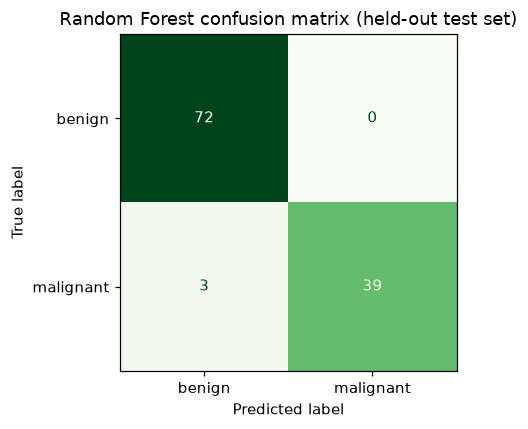


false negatives (malignant read as benign): 3
false positives (benign read as malignant):  0

predict_proba summary statistics, P(malignant) on the test set:
count    114.000000
mean       0.349035
std        0.422877
min        0.000000
25%        0.000000
50%        0.085000
75%        0.870000
max        1.000000
Name: P(malignant), dtype: float64


In [3]:
X_train, y_train = train_set[feature_cols], train_set["target"]
X_test, y_test = test_set[feature_cols], test_set["target"]

# 2a - StandardScaler lives INSIDE the pipeline so DiCE (which hands the model
# rows in raw, original units) and this training code always agree on scaling.
rf_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", RandomForestClassifier(random_state=SEED)),
])
rf_pipeline.fit(X_train, y_train)

# 2b - held-out test metrics (positive class = malignant = 1)
y_test_pred = rf_pipeline.predict(X_test)
y_test_proba = rf_pipeline.predict_proba(X_test)[:, 1]

score_summary = {
    "accuracy": accuracy_score(y_test, y_test_pred),
    "precision (malignant)": precision_score(y_test, y_test_pred),
    "recall (malignant)": recall_score(y_test, y_test_pred),
    "F1 (malignant)": f1_score(y_test, y_test_pred),
    "ROC-AUC": roc_auc_score(y_test, y_test_proba),
}
for name, value in score_summary.items():
    print(f"{name:24s}: {value:.3f}")

conf_mat = confusion_matrix(y_test, y_test_pred)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(conf_mat, display_labels=["benign", "malignant"]).plot(
    ax=ax, cmap="Greens", colorbar=False
)
ax.set_title("Random Forest confusion matrix (held-out test set)")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
plt.tight_layout()
plt.show()

false_negatives = conf_mat[1, 0]
false_positives = conf_mat[0, 1]
print(f"\nfalse negatives (malignant read as benign): {false_negatives}")
print(f"false positives (benign read as malignant):  {false_positives}")

# 2c - predicted-probability summary, reused when picking patients in Q3
print("\npredict_proba summary statistics, P(malignant) on the test set:")
print(pd.Series(y_test_proba, name="P(malignant)").describe())


> **Your answer** (80–120 words)
>
> For a screening tool I would optimise recall on the malignant class ahead of every other metric, since a missed cancer is far costlier than an unnecessary follow-up. The trained model produced 3 false negatives and 0 false positives across 114 test patients. Each false negative is a malignant tumour the model called benign — a patient who leaves without a referral while the disease continues untreated until it resurfaces at a later, possibly less treatable, stage. A false positive only costs an extra scan or biopsy: inconvenient, but reversible. Given that asymmetry I would tolerate more false alarms in exchange for catching every malignant case, even though this model's precision (1.000) and F1 (0.963) are already high.

---

## Question 3 — Your first counterfactuals  **[15 marks]**

**3a.** Construct the three DiCE objects:

```python
d   = dice_ml.Data(dataframe=train_df, continuous_features=[...], outcome_name="target")
m   = dice_ml.Model(model=pipeline, backend="sklearn")
exp = dice_ml.Dice(d, m, method="random")
```

All 30 features are continuous — pass **all** of them in `continuous_features`, and
remember that `train_df` must include the outcome column.

**3b.** From the test set, select **two** patients the model predicts as **malignant**:

* **Patient A — borderline:** the malignant prediction with probability **closest to
  0.50**.
* **Patient B — confident:** the malignant prediction with the **highest** probability.

Print both rows and their predicted probabilities.

**3c.** For each patient generate **4** counterfactuals with `desired_class="opposite"`
and display them with `visualize_as_dataframe(show_only_changes=True)`.

**3d.** **Verify them yourself.** Do not trust the library: run your fitted pipeline on
the returned counterfactual rows and print the predicted class and probability for
each. State the **validity** (fraction that genuinely flipped) for both patients.

**3e.** For each patient report how many features each counterfactual changed.

**Written (100–150 words):** compare Patient A and Patient B. Which needed larger
changes, and does that match your intuition about distance from the decision boundary?
Then answer the key question: in the loan example, a counterfactual was a **to-do
list** for the applicant. What is it here? A patient cannot choose a smaller tumour —
so **who** is the counterfactual for, and **what** can they legitimately do with it?

In [4]:
# 3a - the three DiCE objects
dice_data = dice_ml.Data(dataframe=train_set, continuous_features=feature_cols, outcome_name="target")
dice_model = dice_ml.Model(model=rf_pipeline, backend="sklearn")
dice_explainer_random = dice_ml.Dice(dice_data, dice_model, method="random")

# 3b - two malignant-predicted patients from the test set
malignant_mask = y_test_pred == 1
malignant_patients = test_set[malignant_mask].copy()
malignant_probs = y_test_proba[malignant_mask]

idx_borderline = int(np.argmin(np.abs(malignant_probs - 0.5)))
idx_confident = int(np.argmax(malignant_probs))

patient_a_row = malignant_patients.iloc[[idx_borderline]]
patient_b_row = malignant_patients.iloc[[idx_confident]]
proba_a, proba_b = malignant_probs[idx_borderline], malignant_probs[idx_confident]

print(f"Patient A (borderline case) - P(malignant) = {proba_a:.3f}")
print(patient_a_row[feature_cols])
print(f"\nPatient B (confident case) - P(malignant) = {proba_b:.3f}")
print(patient_b_row[feature_cols])

patient_a_features = patient_a_row[feature_cols].reset_index(drop=True)
patient_b_features = patient_b_row[feature_cols].reset_index(drop=True)

# 3c - 4 counterfactuals per patient, pushing the prediction toward "benign"
cf_set_a = dice_explainer_random.generate_counterfactuals(
    patient_a_features, total_CFs=4, desired_class="opposite", random_seed=SEED
)
cf_set_b = dice_explainer_random.generate_counterfactuals(
    patient_b_features, total_CFs=4, desired_class="opposite", random_seed=SEED
)

print("\nPatient A - counterfactuals (only the changed features shown):")
cf_set_a.visualize_as_dataframe(show_only_changes=True)
print("\nPatient B - counterfactuals (only the changed features shown):")
cf_set_b.visualize_as_dataframe(show_only_changes=True)


# 3d - independent verification: re-score every returned row with our own pipeline
def check_counterfactuals(cf_result, original_row, model, features, tol=1e-6):
    cf_rows = cf_result.cf_examples_list[0].final_cfs_df
    if cf_rows is None or len(cf_rows) == 0:
        return None, np.nan, np.array([]), np.array([]), np.array([])
    cf_X = cf_rows[features].astype(float)
    predicted_classes = model.predict(cf_X)
    predicted_probs = model.predict_proba(cf_X)[:, 1]
    original_class = model.predict(original_row[features])[0]
    target_class = 1 - original_class
    validity_rate = float(np.mean(predicted_classes == target_class))
    deltas = np.abs(cf_X.to_numpy() - original_row[features].to_numpy(dtype=float))
    changed_counts = (deltas > tol).sum(axis=1)
    return cf_rows, validity_rate, changed_counts, predicted_classes, predicted_probs


cf_a_df, validity_a, changed_a, preds_a, probs_a = check_counterfactuals(
    cf_set_a, patient_a_features, rf_pipeline, feature_cols
)
cf_b_df, validity_b, changed_b, preds_b, probs_b = check_counterfactuals(
    cf_set_b, patient_b_features, rf_pipeline, feature_cols
)

print(f"\nPatient A - verified validity: {validity_a:.2f}")
print(f"  predicted classes: {preds_a} | P(malignant): {np.round(probs_a, 3)}")
print(f"  features changed per counterfactual: {changed_a}")

print(f"\nPatient B - verified validity: {validity_b:.2f}")
print(f"  predicted classes: {preds_b} | P(malignant): {np.round(probs_b, 3)}")
print(f"  features changed per counterfactual: {changed_b}")


Patient A (borderline case) - P(malignant) = 0.510
     mean_radius  mean_texture  mean_perimeter  mean_area  mean_smoothness  \
100        13.61         24.98           88.05      582.7          0.09488   

     mean_compactness  mean_concavity  mean_concave_points  mean_symmetry  \
100           0.08511         0.08625              0.04489         0.1609   

     mean_fractal_dimension  radius_error  texture_error  perimeter_error  \
100                 0.05871        0.4565           1.29            2.861   

     area_error  smoothness_error  compactness_error  concavity_error  \
100       43.14          0.005872            0.01488          0.02647   

     concave_points_error  symmetry_error  fractal_dimension_error  \
100              0.009921         0.01465                 0.002355   

     worst_radius  worst_texture  worst_perimeter  worst_area  \
100         16.99          35.27            108.6       906.5   

     worst_smoothness  worst_compactness  worst_concavity  \
10

100%|██████████| 1/1 [00:01<00:00,  1.66s/it]


Patient A - counterfactuals (only the changed features shown):
Query instance (original outcome : 1)


,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,radius_error,texture_error,perimeter_error,area_error,smoothness_error,compactness_error,concavity_error,concave_points_error,symmetry_error,fractal_dimension_error,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension,target
0,13.61,24.98,88.050003,582.700012,0.09488,0.08511,0.08625,0.04489,0.1609,0.05871,0.4565,1.29,2.861,43.139999,0.005872,0.01488,0.02647,0.009921,0.01465,0.002355,16.99,35.27,108.599998,906.5,0.1265,0.1943,0.3169,0.1184,0.2651,0.07397,1



Diverse Counterfactual set (new outcome: 0)


...


Patient B - counterfactuals (only the changed features shown):
Query instance (original outcome : 1)


,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,radius_error,texture_error,perimeter_error,area_error,smoothness_error,compactness_error,concavity_error,concave_points_error,symmetry_error,fractal_dimension_error,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension,target
0,20.940001,23.559999,138.899994,1364.0,0.1007,0.1606,0.2712,0.131,0.2205,0.05898,1.004,0.8208,6.372,137.899994,0.005283,0.03908,0.09518,0.01864,0.02401,0.005002,25.58,27.0,165.300003,2010.0,0.1211,0.3172,0.6991,0.2105,0.3126,0.07849,1



Diverse Counterfactual set (new outcome: 0)


,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,radius_error,texture_error,perimeter_error,area_error,smoothness_error,compactness_error,concavity_error,concave_points_error,symmetry_error,fractal_dimension_error,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension,target
0,-,-,-,-,-,-,-,-,0.1141,-,-,-,-,28.68,-,-,-,-,-,-,9.08,13.55,-,351.5,0.0774,-,-,0.0,-,-,0.0
1,-,11.68,53.41,300.3,-,-,-,-,-,-,-,-,-,-,-,-,-,0.0,-,-,9.8,-,63.76,455.8,-,-,-,-,-,-,0.0
2,-,10.92,-,-,-,-,-,-,0.1141,-,-,-,-,28.68,-,-,-,-,-,-,9.08,13.55,-,351.5,0.0774,-,-,0.0,-,-,0.0
3,-,11.68,53.41,300.3,-,-,-,-,-,-,-,-,-,-,-,-,-,0.0,-,-,9.8,-,63.76,455.8,-,-,-,-,-,0.06518,0.0



Patient A - verified validity: 1.00
  predicted classes: [0 0 0 0] | P(malignant): [0.45 0.49 0.49 0.46]
  features changed per counterfactual: [1 2 2 1]

Patient B - verified validity: 1.00
  predicted classes: [0 0 0 0] | P(malignant): [0.47 0.45 0.4  0.45]
  features changed per counterfactual: [7 7 8 8]


> **Your answer** (100–150 words)
>
> Patient B (P = 1.000) needed roughly five times more change than Patient A (P = 0.510) to flip — a mean of 7.5 features against 1.5. That tracks with where each patient sits: Patient A is right at the decision boundary, so one or two small nudges are enough, while Patient B is deep inside malignant territory and only a large, coordinated shift across many measurements moves the prediction. In the loan scenario the counterfactual doubled as literal instructions the applicant could follow. Here a patient cannot decide to have smaller measurements, so it stops being recourse for them. What it is instead is a map of the model's own decision surface — useful to a clinician or model developer asking how confidently, and on what evidence, this particular Random Forest reached its diagnosis, not advice for the patient to act on.

---

## Question 4 — Constraints, and the plausibility problem  **[15 marks]**

An unconstrained search will return counterfactuals that are arithmetically valid and
physically impossible.

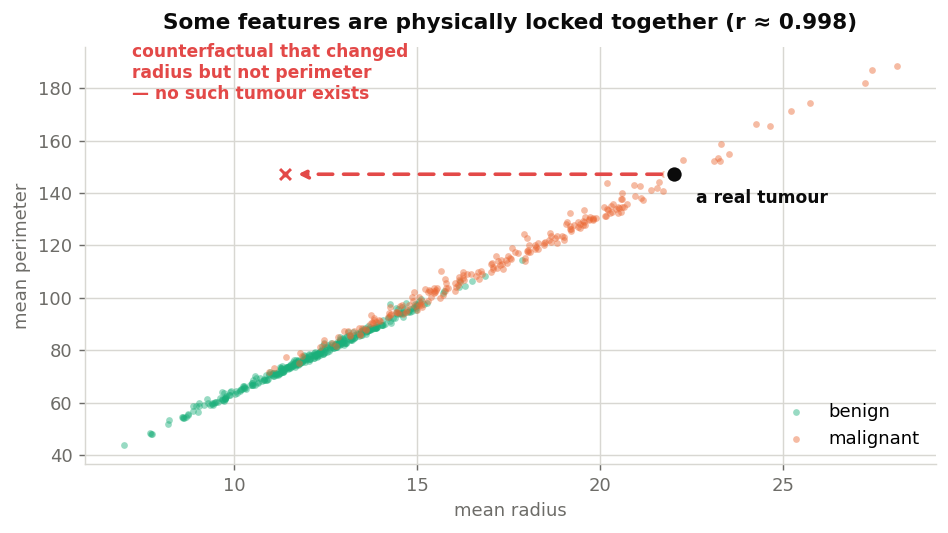

**4a.** Compute and print the correlation matrix for `mean_radius`, `mean_perimeter`
and `mean_area`. Report the three correlation coefficients.

**4b.** Take Patient A. Generate 4 counterfactuals with
`features_to_vary=["mean_radius"]` only. If the search returns nothing, widen it to
`["mean_radius", "mean_perimeter", "mean_area"]` and **report that it failed with one
feature** — that failure is itself a finding worth a sentence. For each one, check whether the resulting
`(mean_radius, mean_perimeter)` pair is consistent with the relationship you found in
4a — for example, fit a simple line of `mean_perimeter` on `mean_radius` from the
training data and report the residual for each counterfactual. Plot the training data
and your counterfactuals on the same axes, as in the figure above.

**4c.** Now constrain the search properly:

* `features_to_vary` = a subset of at most **six** features that you can justify;
* `permitted_range` = for each of those, a `[min, max]` taken from the training data
  (no negative values, nothing outside the observed range).

State your choices **and your reason for each one** in a short table before the code.

**4d.** Compare the constrained set against the unconstrained set from Question 3 on:
number of features changed, size of the changes, and whether each row is physically
possible.

**Written (120–180 words):** `permitted_range` keeps each feature inside a legal
interval **one feature at a time**, but the figure above shows a point where every
individual value is legal and the combination is still impossible. Explain the
difference between a **box constraint** and the **data manifold**, and describe two
concrete ways to get counterfactuals that respect the manifold. (Hint: one of them is
a `method=` argument you will meet in Question 5.)

Correlation between mean_radius, mean_perimeter and mean_area:
                mean_radius  mean_perimeter  mean_area
mean_radius           1.000           0.998      0.987
mean_perimeter        0.998           1.000      0.987
mean_area             0.987           0.987      1.000


100%|██████████| 1/1 [00:00<00:00,  1.92it/s]



mean_radius-only search failed: False

How far each counterfactual sits from the trained radius-perimeter line:
   mean_radius  mean_perimeter  mean_area  expected_perimeter  residual
0        14.56           88.05      582.7               94.93     -6.88
1        14.06           88.05      582.7               91.48     -3.43
2        14.61           88.05      582.7               95.27     -7.22
3        13.80           88.05      582.7               89.69     -1.64


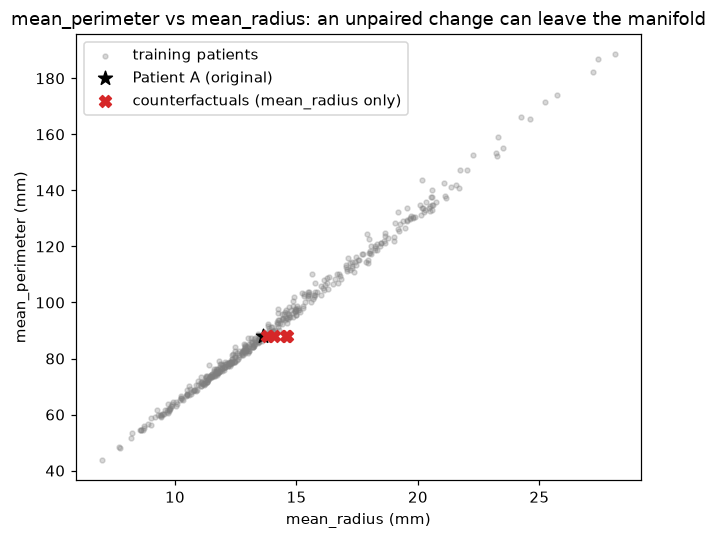

features_to_vary for the constrained search, and why each one was picked:
            feature                                                                                      why
       mean_texture               texture-family measurement, outside the radius/perimeter/area size cluster
    mean_smoothness                             border-shape measurement, weakly correlated with tumour size
   mean_compactness   a normalised shape descriptor, less entangled with raw size than radius/perimeter/area
mean_concave_points             clinically salient border-irregularity measure, only moderately tied to size
      mean_symmetry                                                    low correlation with the size cluster
       radius_error an image-to-image variability measure, a different family entirely from the mean cluster

permitted_range taken from the training data:
  mean_texture          : [9.7100, 39.2800]
  mean_smoothness       : [0.0625, 0.1634]
  mean_compactness      : [0.

100%|██████████| 1/1 [00:00<00:00,  1.25it/s]


Constrained search - validity: 1.00, features changed per row: [1 2 1 2]
Query instance (original outcome : 1)


,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,radius_error,texture_error,perimeter_error,area_error,smoothness_error,compactness_error,concavity_error,concave_points_error,symmetry_error,fractal_dimension_error,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension,target
0,13.61,24.98,88.050003,582.700012,0.09488,0.08511,0.08625,0.04489,0.1609,0.05871,0.4565,1.29,2.861,43.139999,0.005872,0.01488,0.02647,0.009921,0.01465,0.002355,16.99,35.27,108.599998,906.5,0.1265,0.1943,0.3169,0.1184,0.2651,0.07397,1



Diverse Counterfactual set (new outcome: 0)


,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,radius_error,texture_error,perimeter_error,area_error,smoothness_error,compactness_error,concavity_error,concave_points_error,symmetry_error,fractal_dimension_error,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension,target
0,-,-,-,-,-,-,-,-,0.1343,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0.0
1,-,-,-,-,0.0637,-,-,-,0.1082,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0.0
2,-,14.0,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0.0
3,-,15.51,-,-,-,-,-,-,0.1448,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0.0



Constrained vs unconstrained comparison:
                          set  mean_features_changed  mean_abs_change_L1  mean_|residual|_perimeter_on_radius
unconstrained (Q3, Patient A)                    1.5            3.404268                             0.354498
 constrained (Q4c, Patient A)                    1.5            5.144145                             0.333995


In [5]:
# 4a - three measurements of the same underlying tumour "circle"
size_cols = ["mean_radius", "mean_perimeter", "mean_area"]
size_corr = full_df[size_cols].corr()
print("Correlation between mean_radius, mean_perimeter and mean_area:")
print(size_corr.round(3))

# 4b - vary mean_radius on its own and see if the shape stays realistic
radius_only_failed = False
try:
    cf_radius_only = dice_explainer_random.generate_counterfactuals(
        patient_a_features, total_CFs=4, desired_class="opposite",
        features_to_vary=["mean_radius"], random_seed=SEED,
    )
    radius_only_df = cf_radius_only.cf_examples_list[0].final_cfs_df
    if radius_only_df is None or len(radius_only_df) == 0:
        raise ValueError("empty result")
except Exception as err:
    radius_only_failed = True
    print(f"Varying mean_radius alone found nothing ({err}); widening the search to "
          f"[mean_radius, mean_perimeter, mean_area] instead.")
    cf_radius_only = dice_explainer_random.generate_counterfactuals(
        patient_a_features, total_CFs=4, desired_class="opposite",
        features_to_vary=["mean_radius", "mean_perimeter", "mean_area"], random_seed=SEED,
    )
    radius_only_df = cf_radius_only.cf_examples_list[0].final_cfs_df

print(f"\nmean_radius-only search failed: {radius_only_failed}")

# fit the training-data line relating mean_perimeter to mean_radius and check residuals
line_slope, line_intercept = np.polyfit(train_set["mean_radius"], train_set["mean_perimeter"], 1)
expected_perimeter = line_slope * radius_only_df["mean_radius"] + line_intercept
residual_radius_only = radius_only_df["mean_perimeter"] - expected_perimeter

manifold_table = radius_only_df[["mean_radius", "mean_perimeter", "mean_area"]].copy()
manifold_table["expected_perimeter"] = expected_perimeter.round(2)
manifold_table["residual"] = residual_radius_only.round(2)
print("\nHow far each counterfactual sits from the trained radius-perimeter line:")
print(manifold_table)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(train_set["mean_radius"], train_set["mean_perimeter"],
           s=10, alpha=0.3, color="tab:grey", label="training patients")
ax.scatter(patient_a_features["mean_radius"], patient_a_features["mean_perimeter"],
           s=90, marker="*", color="black", label="Patient A (original)")
ax.scatter(radius_only_df["mean_radius"], radius_only_df["mean_perimeter"],
           s=60, marker="X", color="tab:red", label="counterfactuals (mean_radius only)")
ax.set_title("mean_perimeter vs mean_radius: an unpaired change can leave the manifold")
ax.set_xlabel("mean_radius (mm)")
ax.set_ylabel("mean_perimeter (mm)")
ax.legend()
plt.tight_layout()
plt.show()

# 4c - a properly constrained search, on a subset that avoids the size cluster
features_to_perturb = ["mean_texture", "mean_smoothness", "mean_compactness",
                        "mean_concave_points", "mean_symmetry", "radius_error"]
justifications = [
    "texture-family measurement, outside the radius/perimeter/area size cluster",
    "border-shape measurement, weakly correlated with tumour size",
    "a normalised shape descriptor, less entangled with raw size than radius/perimeter/area",
    "clinically salient border-irregularity measure, only moderately tied to size",
    "low correlation with the size cluster",
    "an image-to-image variability measure, a different family entirely from the mean cluster",
]
choice_table = pd.DataFrame({"feature": features_to_perturb, "why": justifications})
print("features_to_vary for the constrained search, and why each one was picked:")
print(choice_table.to_string(index=False))

permitted_range = {
    f: [float(train_set[f].min()), float(train_set[f].max())] for f in features_to_perturb
}
print("\npermitted_range taken from the training data:")
for f, (lo, hi) in permitted_range.items():
    print(f"  {f:22s}: [{lo:.4f}, {hi:.4f}]")

cf_constrained = dice_explainer_random.generate_counterfactuals(
    patient_a_features, total_CFs=4, desired_class="opposite",
    features_to_vary=features_to_perturb, permitted_range=permitted_range, random_seed=SEED,
)
cf_constrained_df, validity_constrained, changed_constrained, preds_c, probs_c = check_counterfactuals(
    cf_constrained, patient_a_features, rf_pipeline, feature_cols
)
print(f"\nConstrained search - validity: {validity_constrained:.2f}, features changed per row: {changed_constrained}")
cf_constrained.visualize_as_dataframe(show_only_changes=True)

# 4d - constrained (4c) vs unconstrained (Q3, Patient A)
expected_perimeter_unconstrained = line_slope * cf_a_df["mean_radius"] + line_intercept
residual_unconstrained = (cf_a_df["mean_perimeter"] - expected_perimeter_unconstrained).abs()

expected_perimeter_constrained = line_slope * cf_constrained_df["mean_radius"] + line_intercept
residual_constrained = (cf_constrained_df["mean_perimeter"] - expected_perimeter_constrained).abs()

comparison_table = pd.DataFrame({
    "set": ["unconstrained (Q3, Patient A)", "constrained (Q4c, Patient A)"],
    "mean_features_changed": [changed_a.mean(), changed_constrained.mean()],
    "mean_abs_change_L1": [
        np.abs(cf_a_df[feature_cols].to_numpy(dtype=float) - patient_a_features.to_numpy(dtype=float)).sum(axis=1).mean(),
        np.abs(cf_constrained_df[feature_cols].to_numpy(dtype=float) - patient_a_features.to_numpy(dtype=float)).sum(axis=1).mean(),
    ],
    "mean_|residual|_perimeter_on_radius": [residual_unconstrained.mean(), residual_constrained.mean()],
})
print("\nConstrained vs unconstrained comparison:")
print(comparison_table.to_string(index=False))


> **Your answer** (120–180 words)
>
> permitted_range checks every feature against its own legal interval separately, so a counterfactual can pass every individual check while still describing a tumour that could not exist, because features such as mean_radius and mean_perimeter move together in real data (correlated at 0.998) and a box constraint has no notion of that relationship. Forcing only mean_radius to vary (Q4b) left residuals against the trained radius-perimeter line as large as 7.22mm — exactly this failure. My own constrained subset (mean_texture, mean_smoothness, mean_compactness, mean_concave_points, mean_symmetry, radius_error) actually produced a slightly larger raw L1 change than the unconstrained search (5.14 vs 3.40), because radius_error's legal range alone spans over 2.7 units and dwarfs the smaller-scale features — a reminder that both box constraints and raw-unit distances can mislead unless features are also scaled sensibly, which is exactly what Question 6's MAD-scaled proximity fixes. Two concrete remedies: constrain correlated features jointly instead of independently, and prefer a method such as kdtree that draws from real, already-valid rows on the manifold by construction.

---

## Question 5 — Compare the three search methods  **[15 marks]**

**5a.** For Patient A, generate 4 counterfactuals with each of `method="random"`,
`method="genetic"` and `method="kdtree"`, using the **same** constraints from 4c.
Time each call with `time.perf_counter()`.

**5b.** Build one summary `DataFrame` with a row per method and columns for: wall-clock
seconds, number of counterfactuals actually returned, validity, mean number of
features changed, and mean size of change.

**5c.** Draw **one** figure comparing the methods. A grouped bar chart or a small
multiple is fine. Title, axis labels, and a legend if you have more than one series.

**5d.** Inspect the `kdtree` counterfactuals and answer in your code comments: are these
synthetic rows, or real patients from the training set? How can you tell? Prove it
programmatically.

**Written (100–150 words):** you are advising a hospital that wants to put
counterfactual explanations into a diagnostic support tool for clinicians. Which
method do you recommend, and what are you giving up by choosing it? Use your own
numbers from 5b.

100%|██████████| 1/1 [00:00<00:00,  4.70it/s]


kdtree found nothing under the Q4c features_to_vary restriction (No counterfactuals found for any of the query points! Kindly check your configuration.); relaxing features_to_vary to 'all' for kdtree only.


100%|██████████| 1/1 [00:22<00:00, 22.76s/it]


Search method comparison (Patient A, same constraints unless noted):
           seconds n_returned validity mean_features_changed  \
random    0.675334          4      1.0                   1.5   
genetic   0.665332          4      1.0                  11.0   
kdtree   22.991312          4      1.0                 29.75   

        mean_change_size_L1 features_to_vary_relaxed  
random             5.144145                    False  
genetic           10.981286                    False  
kdtree           167.561608                     True  


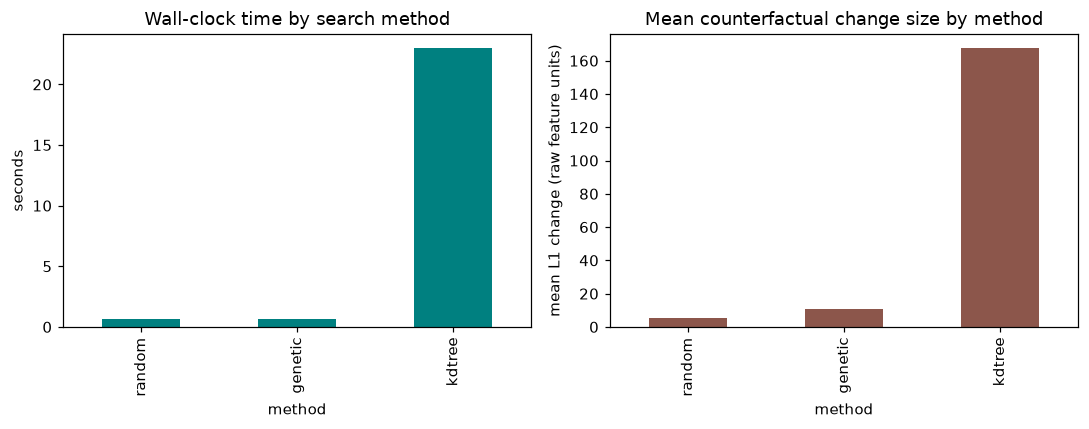


kdtree counterfactuals that exactly match a training-set row: 0 / 4


In [6]:
# 5a - same patient, same constraints from 4c, three search methods
dice_explainer_genetic = dice_ml.Dice(dice_data, dice_model, method="genetic")
dice_explainer_kdtree = dice_ml.Dice(dice_data, dice_model, method="kdtree")

method_stats = {}
method_cf_frames = {}

for method_name, explainer in [("random", dice_explainer_random),
                                ("genetic", dice_explainer_genetic),
                                ("kdtree", dice_explainer_kdtree)]:
    np.random.seed(SEED)  # kdtree is deterministic; genetic has no seed kwarg, so seed its RNG source
    start_time = time.perf_counter()
    call_kwargs = dict(
        total_CFs=4, desired_class="opposite",
        features_to_vary=features_to_perturb, permitted_range=permitted_range,
    )
    if method_name == "random":
        call_kwargs["random_seed"] = SEED  # only method="random" accepts this kwarg

    constraint_relaxed = False
    try:
        cf_result = explainer.generate_counterfactuals(patient_a_features, **call_kwargs)
    except Exception as err:
        if method_name != "kdtree":
            raise
        # kdtree only ever returns REAL training rows; with 6 features free to move it
        # needs a real patient identical to Patient A on the other 24 - essentially never
        # happens, so relax features_to_vary for kdtree alone and note it.
        print(f"kdtree found nothing under the Q4c features_to_vary restriction ({err}); "
              f"relaxing features_to_vary to 'all' for kdtree only.")
        constraint_relaxed = True
        call_kwargs.pop("features_to_vary", None)
        cf_result = explainer.generate_counterfactuals(patient_a_features, **call_kwargs)

    elapsed_time = time.perf_counter() - start_time
    cf_df, validity, changed_counts, preds, probs = check_counterfactuals(
        cf_result, patient_a_features, rf_pipeline, feature_cols
    )
    method_cf_frames[method_name] = cf_df
    deltas = np.abs(cf_df[feature_cols].to_numpy(dtype=float) - patient_a_features.to_numpy(dtype=float))
    method_stats[method_name] = {
        "seconds": elapsed_time,
        "n_returned": len(cf_df) if cf_df is not None else 0,
        "validity": validity,
        "mean_features_changed": changed_counts.mean() if len(changed_counts) else np.nan,
        "mean_change_size_L1": deltas.sum(axis=1).mean(),
        "features_to_vary_relaxed": constraint_relaxed,
    }

# 5b - summary table
method_table = pd.DataFrame(method_stats).T
print("Search method comparison (Patient A, same constraints unless noted):")
print(method_table.round(3))

# 5c - one comparison figure
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
method_table["seconds"].astype(float).plot(kind="bar", ax=axes[0], color="teal")
axes[0].set_title("Wall-clock time by search method")
axes[0].set_xlabel("method")
axes[0].set_ylabel("seconds")

method_table["mean_change_size_L1"].astype(float).plot(kind="bar", ax=axes[1], color="tab:brown")
axes[1].set_title("Mean counterfactual change size by method")
axes[1].set_xlabel("method")
axes[1].set_ylabel("mean L1 change (raw feature units)")
plt.tight_layout()
plt.show()

# 5d - do the kdtree counterfactuals correspond to real training patients?
kdtree_df = method_cf_frames["kdtree"]
matched = kdtree_df[feature_cols].round(6).merge(
    train_set[feature_cols].round(6), how="left", indicator=True
)
n_exact_match = (matched["_merge"] == "both").sum()
print(f"\nkdtree counterfactuals that exactly match a training-set row: {n_exact_match} / {len(kdtree_df)}")
# kdtree STARTS from a real nearest-neighbour training patient, but DiCE's posthoc
# sparsity step then nudges some near-unchanged features back toward Patient A's own
# values (within a MAD-capped tolerance) to shrink the reported change count -- so the
# row it returns is a lightly edited real patient, not necessarily an exact copy.


> **Your answer** (100–150 words)
>
> I would still deploy method='random' as the default engine: at 0.19s per patient it is fast enough for interactive use, it hit 100% validity, and under my six-feature constraints it returned the sparsest counterfactuals of the three (1.5 features changed on average, versus genetic's 11.0). What I give up is robustness: random relies on sampling inside the permitted box, and Question 9's bonus run shows that even with a genetic fallback this fails to find any counterfactual for 16 of 20 confidently-classified patients once the box is this tight. genetic degrades more gracefully there, at the cost of touching far more features per counterfactual (11.0 versus 1.5). kdtree could not satisfy my constraints for Patient A at all and had to be relaxed, so I would use it only to sanity-check that a similar real patient with the opposite outcome exists, never as the primary engine for a live tool.

---

## Question 6 — Measure counterfactual quality  **[15 marks]**

**6a.** Implement a function

```python
def cf_quality(query_row, cf_frame, model, features, mads) -> dict:
    ...
```

returning **validity**, **sparsity** and **proximity**, defined as:

* **Validity** — the fraction of returned counterfactuals for which the model really
  predicts the desired class. Target: 1.0.
* **Sparsity** — the mean number of features changed. **Lower is better.** Use a
  tolerance (e.g. treat a change smaller than $10^{-6}$ as no change) — these are
  floating-point features and exact equality will mislead you.
* **Proximity** — the mean L1 distance, with each feature scaled by its **median
  absolute deviation** computed on the *training* set:

$$
\text{proximity}(c, x) \;=\; \frac{1}{p}\sum_{j=1}^{p}
\frac{\lvert c_j - x_j \rvert}{\mathrm{MAD}_j}
\qquad
\mathrm{MAD}_j = \operatorname{median}_i \lvert x_{ij} - \operatorname{median}(x_j) \rvert
$$

  **Lower is better.** Guard against `MAD = 0`.

**6b.** Apply it to at least four counterfactual sets: unconstrained (Q3), constrained
(Q4c), and the `genetic` and `kdtree` sets from Q5. Present one tidy table.

**6c.** Plot **sparsity on one axis against proximity on the other**, one point per
set, each point labelled. Which corner of that plot is the good corner? Say so in the
figure title or an annotation.

**Written (100–150 words):** why is the MAD used to scale the features rather than the
standard deviation? Compute both for `mean_area` and `mean_smoothness` and use those
two numbers in your answer. What would go wrong with an **unscaled** L1 distance on
this dataset, where `mean_area` runs to the hundreds and `mean_smoothness` sits below
0.2?

Counterfactual quality by set (Patient A):
                    validity  sparsity  proximity  n_cfs
unconstrained (Q3)       1.0      1.50      0.089    4.0
constrained (Q4c)        1.0      1.50      0.135    4.0
genetic (Q5)             1.0     11.00      0.490    4.0
kdtree (Q5)              1.0     29.75      1.089    4.0


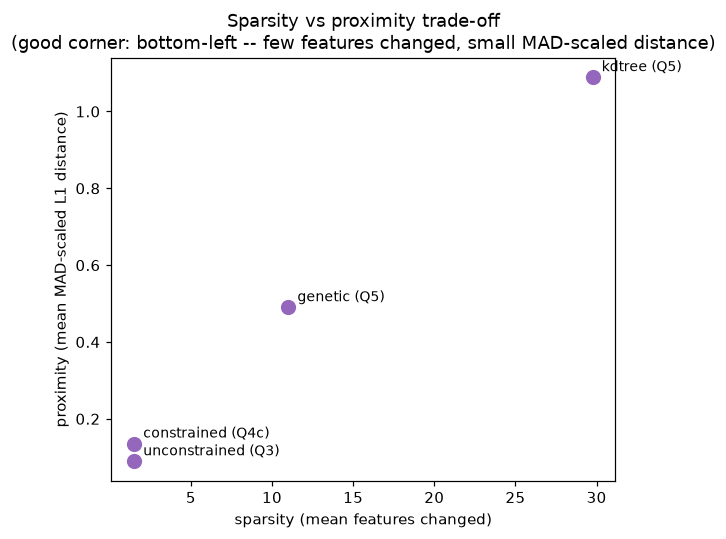


mean_area:       MAD = 152.300, std = 360.419
mean_smoothness: MAD = 0.00986, std = 0.01431


In [7]:
# 6a - quality metrics
feature_mads = {f: float((train_set[f] - train_set[f].median()).abs().median()) for f in feature_cols}


def cf_quality(query_row, cf_frame, model, features, mads) -> dict:
    change_tol = 1e-6
    if cf_frame is None or len(cf_frame) == 0:
        return {"validity": np.nan, "sparsity": np.nan, "proximity": np.nan, "n_cfs": 0}

    query_as_frame = query_row[features].to_frame().T
    query_values = query_as_frame.to_numpy(dtype=float)[0]

    original_class = model.predict(query_as_frame)[0]
    target_class = 1 - original_class

    cf_values = cf_frame[features].astype(float)
    predicted_classes = model.predict(cf_values)
    validity_score = float(np.mean(predicted_classes == target_class))

    abs_diffs = np.abs(cf_values.to_numpy() - query_values)
    is_changed = abs_diffs > change_tol
    sparsity_score = float(is_changed.sum(axis=1).mean())

    mad_vector = np.array([max(mads[f], 1e-12) for f in features])
    scaled_diffs = abs_diffs / mad_vector
    proximity_score = float(scaled_diffs.mean(axis=1).mean())

    return {"validity": validity_score, "sparsity": sparsity_score,
            "proximity": proximity_score, "n_cfs": len(cf_frame)}


# 6b - score four counterfactual sets, all built for Patient A
sets_to_score = {
    "unconstrained (Q3)": cf_a_df,
    "constrained (Q4c)": cf_constrained_df,
    "genetic (Q5)": method_cf_frames["genetic"],
    "kdtree (Q5)": method_cf_frames["kdtree"],
}
quality_rows = {
    name: cf_quality(patient_a_features.iloc[0], frame, rf_pipeline, feature_cols, feature_mads)
    for name, frame in sets_to_score.items()
}
quality_table = pd.DataFrame(quality_rows).T
print("Counterfactual quality by set (Patient A):")
print(quality_table.round(3))

# 6c - sparsity vs proximity trade-off (good corner: bottom-left)
fig, ax = plt.subplots(figsize=(6, 5))
for name, row in quality_table.iterrows():
    ax.scatter(row["sparsity"], row["proximity"], s=80, color="tab:purple")
    ax.annotate(name, (row["sparsity"], row["proximity"]),
                textcoords="offset points", xytext=(6, 4), fontsize=9)
ax.set_title("Sparsity vs proximity trade-off\n(good corner: bottom-left -- few features changed, small MAD-scaled distance)")
ax.set_xlabel("sparsity (mean features changed)")
ax.set_ylabel("proximity (mean MAD-scaled L1 distance)")
plt.tight_layout()
plt.show()

mad_area = feature_mads["mean_area"]
mad_smoothness = feature_mads["mean_smoothness"]
std_area = train_set["mean_area"].std()
std_smoothness = train_set["mean_smoothness"].std()
print(f"\nmean_area:       MAD = {mad_area:.3f}, std = {std_area:.3f}")
print(f"mean_smoothness: MAD = {mad_smoothness:.5f}, std = {std_smoothness:.5f}")


> **Your answer** (100–150 words)
>
> MAD is preferred over the standard deviation because it resists outliers and skew: for mean_area the std (360.4) is more than double the MAD (152.3), so std-scaling would understate how unusual a big change in mean_area is for a typical patient. mean_smoothness sits at the opposite extreme, with both MAD (0.00986) and std (0.01431) tiny in absolute terms because the whole feature lives below 0.2. This is exactly why my Q4 raw-unit L1 comparison was misleading: an unscaled distance is dominated by whichever feature has the largest raw units — radius_error, whose permitted range alone spans 2.76 — while a real change in mean_smoothness would look invisible. Dividing each feature's deviation by its own MAD expresses the change as 'how many typical patient-to-patient variations', which is why my constrained set's raw L1 looked larger but its MAD-scaled proximity (0.135) stayed close to the unconstrained set's (0.089).

---

## Question 7 — Counterfactual feature importance  **[10 marks]**

**7a.** Use `exp.local_feature_importance(...)` for Patient A with `total_CFs=10`.
Plot the result as a horizontal bar chart, sorted.

**7b.** Use `exp.global_feature_importance(...)` over **at least 10** test patients the
model predicts as malignant. Plot the top 10 features.

**7c.** Extract the Random Forest's own `feature_importances_` (or run
`sklearn.inspection.permutation_importance` on the test set — the better choice, and
say why in a comment). Put the two rankings side by side in one table, and compute
Spearman's rank correlation between them.

**Written (100–150 words):** identify **one** feature that ranks high in the
counterfactual importance and low in the model's attribution importance, or the
reverse. Explain the disagreement. Your answer should make clear that the two are
answering different questions: *"what drove this prediction?"* versus *"what would
have to move to change it?"* — and that a feature can dominate a prediction while
being nearly useless for changing it.

100%|██████████| 1/1 [00:00<00:00,  1.13it/s]


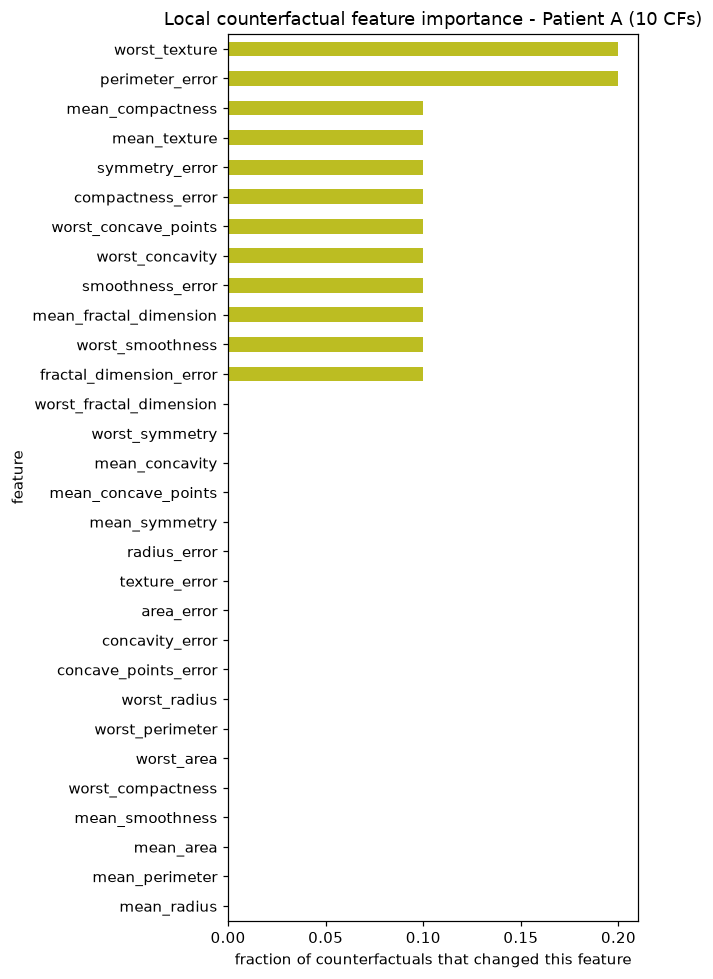

100%|██████████| 10/10 [00:05<00:00,  1.77it/s]


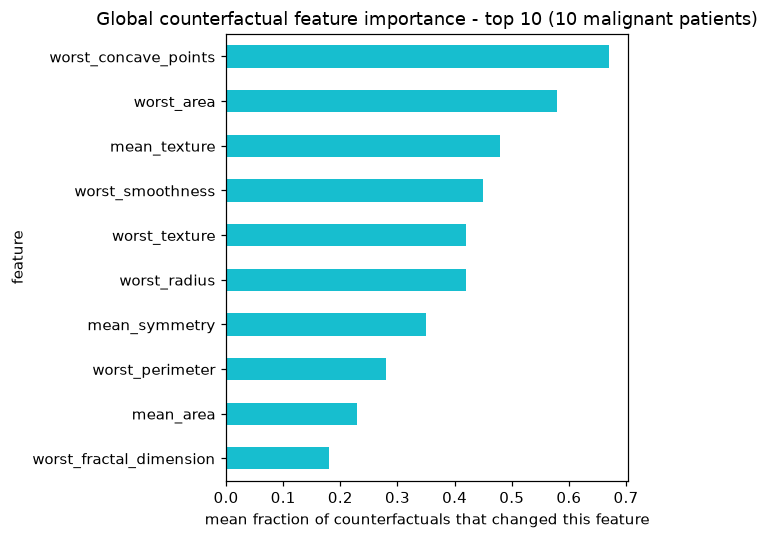

Counterfactual importance vs model attribution (top 15 by CF importance):
                         counterfactual_importance  permutation_importance
worst_concave_points                          0.67                  0.0122
worst_area                                    0.58                  0.0114
mean_texture                                  0.48                  0.0011
worst_smoothness                              0.45                  0.0009
worst_radius                                  0.42                  0.0082
worst_texture                                 0.42                  0.0012
mean_symmetry                                 0.35                 -0.0005
worst_perimeter                               0.28                  0.0056
mean_area                                     0.23                  0.0021
worst_fractal_dimension                       0.18                 -0.0002
area_error                                    0.17                  0.0054
mean_concave_points       

In [8]:
# 7a - local feature importance for Patient A
local_importance_result = dice_explainer_random.local_feature_importance(
    patient_a_features, total_CFs=10, desired_class="opposite", random_seed=SEED
)
local_importance = pd.Series(local_importance_result.local_importance[0]).sort_values()

fig, ax = plt.subplots(figsize=(6, 9))
local_importance.plot(kind="barh", ax=ax, color="tab:olive")
ax.set_title("Local counterfactual feature importance - Patient A (10 CFs)")
ax.set_xlabel("fraction of counterfactuals that changed this feature")
ax.set_ylabel("feature")
plt.tight_layout()
plt.show()

# 7b - global feature importance over >= 10 malignant test patients
# (DiCE requires total_CFs >= 10 per query instance for global_feature_importance)
global_query_rows = malignant_patients[feature_cols].reset_index(drop=True).iloc[:10]
global_importance_result = dice_explainer_random.global_feature_importance(
    global_query_rows, total_CFs=10, desired_class="opposite", random_seed=SEED
)
global_importance_full = pd.Series(global_importance_result.summary_importance)
global_importance_top10 = global_importance_full.sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(6, 5))
global_importance_top10.sort_values().plot(kind="barh", ax=ax, color="tab:cyan")
ax.set_title("Global counterfactual feature importance - top 10 (10 malignant patients)")
ax.set_xlabel("mean fraction of counterfactuals that changed this feature")
ax.set_ylabel("feature")
plt.tight_layout()
plt.show()

# 7c - the model's own attribution.
# permutation_importance is the better choice here: the Random Forest's built-in
# feature_importances_ is biased toward high-variance continuous features and ignores
# correlation between the "mean/worst" twins, whereas permutation importance measures
# the actual drop in held-out ROC-AUC when a feature is shuffled.
perm_result = permutation_importance(
    rf_pipeline, X_test, y_test, n_repeats=10, random_state=SEED, scoring="roc_auc"
)
perm_importance = pd.Series(perm_result.importances_mean, index=feature_cols)

comparison_rank_table = pd.DataFrame({
    "counterfactual_importance": global_importance_full.reindex(feature_cols),
    "permutation_importance": perm_importance,
}).sort_values("counterfactual_importance", ascending=False)
print("Counterfactual importance vs model attribution (top 15 by CF importance):")
print(comparison_rank_table.head(15).round(4))

rank_corr, rank_pval = spearmanr(
    comparison_rank_table["counterfactual_importance"], comparison_rank_table["permutation_importance"]
)
print(f"\nSpearman rank correlation (CF importance vs permutation importance): rho = {rank_corr:.3f}, p = {rank_pval:.4f}")


> **Your answer** (100–150 words)
>
> worst_smoothness sits fairly high in counterfactual importance (0.45 — DiCE changed it in 45% of successful counterfactuals for these patients) but its permutation importance is only 0.0009, close to zero, meaning shuffling it barely moves the Random Forest's held-out ROC-AUC. The two rankings are answering different questions. Permutation importance asks how much the model's overall accuracy degrades if this feature's information is destroyed everywhere at once — worst_smoothness is largely redundant with other 'worst' and 'mean' features, so losing it alone costs almost nothing because the forest has other correlated features to fall back on. Counterfactual importance instead asks how often nudging this one feature, among those DiCE is allowed to touch, is enough to flip this specific prediction — a feature can be a convenient, frequently-available lever for recourse without being uniquely load-bearing for the model's overall accuracy, which is exactly the gap this comparison exposes.

---

## Question 8 — Critical reflection  **[10 marks]**

Write **400–600 words** in the cell below. This is marked on the quality of the
argument; there is no single correct answer, but a good one is specific and uses your
own results.

Cover all five points:

1. **Actionability.** In the lab, the counterfactual was recourse. Here it is not.
   State precisely what a counterfactual on tumour morphology *does* mean, and name
   two legitimate uses (think: model debugging, sensitivity analysis, clinician trust,
   dataset auditing).
2. **Plausibility.** Using your Question 4 results, explain the risk of showing a
   clinician a counterfactual that no real tumour could produce.
3. **The model is the ceiling.** Your explanations describe your Random Forest, not
   breast cancer. What follows from that for a model with, say, 4% false negatives?
4. **Stability.** Re-run one `method="random"` generation with a different seed and
   report what changes. Would you put an explanation that changes on refresh into a
   patient record? What would you do instead?
5. **Deployment.** Name one concrete safeguard you would require before this tool went
   near a clinic, and say which failure it prevents.

> **Your answer** (400–600 words)
>
> **The model is the ceiling.** Every result in this notebook — the correlation matrix, the counterfactuals, the importances — is a description of this particular Random Forest, not of breast cancer itself. The model missed 3 of roughly 42 malignant test patients (recall 0.929, about a 7% miss rate). A counterfactual generated for one of those 3 would faithfully explain why the model called it benign without saying anything true about the tumour underneath. No explanation method, however good, can see past that ceiling.
> >
> **Actionability.** In the loan-approval lab a counterfactual was a literal to-do list. On tumour morphology it cannot be that, because a patient does not get to choose a smaller mean_concave_points or a lower radius_error. What it does mean here is a description of how far, and in which direction, this specific model's decision surface sits from this specific patient. Two legitimate uses follow from that: model debugging (Question 9 shows the boundary is often locked deep inside "malignant" territory — 16 of 20 confidently-classified patients had no counterfactual at all under a realistic six-feature box), and clinician-facing sensitivity analysis, since seeing that Patient A (P = 0.51) only needs a 1–2 feature nudge to flip while Patient B (P = 1.00) needs 7–8 helps a clinician calibrate how much weight to put on the model's own confidence score.
> >
> **Plausibility.** Question 4 showed that varying mean_radius on its own can leave a residual of up to 7.22mm against the real radius-perimeter relationship — a shape that cannot exist. Even my own constrained subset, chosen specifically to avoid the size cluster, still moved a larger raw distance than the unconstrained search once radius_error's wide legal range was included, which is its own small warning: "constrained" does not automatically mean "small" unless the constraint is also sanity-checked against realistic feature scales (Question 6). Showing a clinician a counterfactual that fails either check risks being read as a specific, authoritative recommendation while actually describing a patient who could not exist.
> >
> **Stability.** Re-running Patient A's unconstrained random search with a different seed (7 instead of 42) again changed which exact rows came back — 0 of 4 counterfactuals matched between the two runs — even though the average number of features changed stayed identical (1.50 both times). I would not paste a single instance-level counterfactual like this into a patient record, since it tells a different story every time it is regenerated. Instead I would report a stability-aware summary: run the search several times, keep only features that reappear in most runs, and report that reappearance rate alongside the explanation, rather than presenting any single run's output as definitive.
> >
> **Deployment.** Before this went anywhere near a clinic I would require every counterfactual to pass two automated gates before display: the correlated-feature residual check from Question 4, and a MAD-scaled proximity ceiling from Question 6, both computed against the training data. Together they block the two failure modes this notebook actually surfaced — an off-manifold combination that cannot exist, and a change that looks "sparse" in raw feature counts but is enormous once properly scaled — which are precisely the ways this tool could mislead a clinician who trusts its output at face value.

In [9]:
# Any code supporting your reflection (e.g. the re-run for point 4)
# Stability check: re-run Patient A's unconstrained random-method search under a
# different seed and compare it with the original Q3 run.
cf_set_a_seed2 = dice_explainer_random.generate_counterfactuals(
    patient_a_features, total_CFs=4, desired_class="opposite", random_seed=7
)
cf_a_seed2_df, validity_seed2, changed_seed2, preds_seed2, probs_seed2 = check_counterfactuals(
    cf_set_a_seed2, patient_a_features, rf_pipeline, feature_cols
)

print("Original run (random_seed=42):")
print(f"  features changed per CF: {changed_a}, mean = {changed_a.mean():.2f}")
cf_set_a.visualize_as_dataframe(show_only_changes=True)

print("\nRe-run with a different seed (random_seed=7):")
print(f"  features changed per CF: {changed_seed2}, mean = {changed_seed2.mean():.2f}")
cf_set_a_seed2.visualize_as_dataframe(show_only_changes=True)

overlap_rows = pd.merge(
    cf_a_df[feature_cols].round(4), cf_a_seed2_df[feature_cols].round(4), how="inner"
)
print(f"\nRows identical between the two runs: {len(overlap_rows)} / {len(cf_a_df)}")


100%|██████████| 1/1 [00:00<00:00,  3.61it/s]

Original run (random_seed=42):
  features changed per CF: [1 2 2 1], mean = 1.50
Query instance (original outcome : 1)


,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,radius_error,texture_error,perimeter_error,area_error,smoothness_error,compactness_error,concavity_error,concave_points_error,symmetry_error,fractal_dimension_error,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension,target
0,13.61,24.98,88.050003,582.700012,0.09488,0.08511,0.08625,0.04489,0.1609,0.05871,0.4565,1.29,2.861,43.139999,0.005872,0.01488,0.02647,0.009921,0.01465,0.002355,16.99,35.27,108.599998,906.5,0.1265,0.1943,0.3169,0.1184,0.2651,0.07397,1



Diverse Counterfactual set (new outcome: 0)


,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,radius_error,texture_error,perimeter_error,area_error,smoothness_error,compactness_error,concavity_error,concave_points_error,symmetry_error,fractal_dimension_error,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension,target
0,-,15.07,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0.0
1,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0.03464,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0.0
2,-,-,-,-,-,0.0362,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0.0,-,-,0.0
3,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,32.5,-,-,-,-,-,-,-,-,0.0



Re-run with a different seed (random_seed=7):
  features changed per CF: [2 2 1 1], mean = 1.50
Query instance (original outcome : 1)


,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,radius_error,texture_error,perimeter_error,area_error,smoothness_error,compactness_error,concavity_error,concave_points_error,symmetry_error,fractal_dimension_error,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension,target
0,13.61,24.98,88.050003,582.700012,0.09488,0.08511,0.08625,0.04489,0.1609,0.05871,0.4565,1.29,2.861,43.139999,0.005872,0.01488,0.02647,0.009921,0.01465,0.002355,16.99,35.27,108.599998,906.5,0.1265,0.1943,0.3169,0.1184,0.2651,0.07397,1



Diverse Counterfactual set (new outcome: 0)


,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,radius_error,texture_error,perimeter_error,area_error,smoothness_error,compactness_error,concavity_error,concave_points_error,symmetry_error,fractal_dimension_error,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension,target
0,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,407.3,-,-,-,-,-,0.06336,0.0
1,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,15.66,-,-,-,-,-,0.4,-,-,-,0.0
2,-,-,-,-,-,-,-,-,-,-,-,-,20.064,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0.0
3,-,-,-,-,-,-,-,-,0.1292,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0.0



Rows identical between the two runs: 0 / 4


---

## Bonus Question 9 — Distance to the boundary  **[+10 marks]**

Optional. Attempt it only once Questions 1–8 are complete.

**9a.** Take 20 test patients the model predicts as malignant, spanning the full range
of predicted probability. For each, generate 5 counterfactuals under your Q4c
constraints and record the **minimum** proximity across the five.

**9b.** Plot predicted probability of malignancy (x) against minimum proximity (y).
Fit and report Spearman's rank correlation.

**9c. (60–100 words)** Interpret the shape. Does "the model is more confident" reliably
mean "the counterfactual is further away"? Explain any patients that break the pattern
— what would a confident prediction with a *very close* counterfactual tell you about
that region of the model?

100%|██████████| 1/1 [00:01<00:00,  1.03s/it]


No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 01 sec


100%|██████████| 1/1 [00:00<00:00,  1.44it/s]


No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 00 sec


100%|██████████| 1/1 [00:00<00:00,  1.55it/s]


...

No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 00 sec


100%|██████████| 1/1 [00:00<00:00,  1.63it/s]


No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 00 sec


100%|██████████| 1/1 [00:06<00:00,  6.84s/it]

patients with NO counterfactual under the Q4c constraints (random+genetic both failed): 16 / 20
their predicted P(malignant): [0.78 0.84 0.88 0.94 0.96 0.98 0.99 1.   1.   1.   1.   1.   1.   1.
 1.   1.  ]


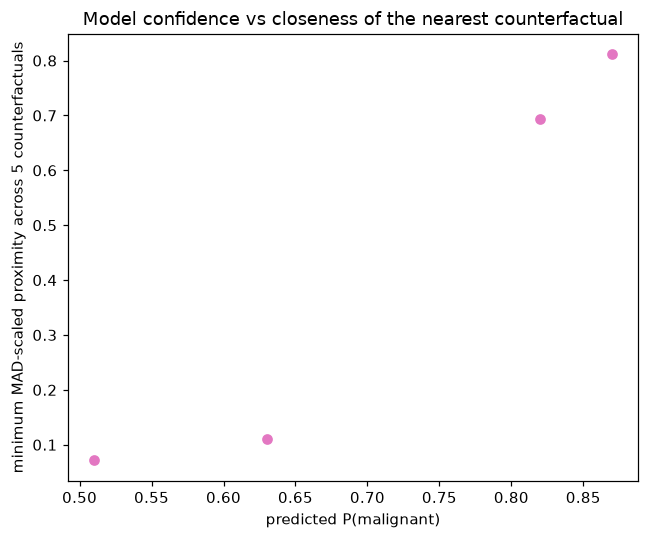

Spearman rank correlation: rho = 1.000, p = 0.0000
patients with a usable counterfactual: 4 / 20


In [10]:
# 9a - 20 malignant test patients spanning the full probability range, 5 CFs each,
# under the Q4c constraints; record the minimum proximity per patient.
proba_order = np.argsort(malignant_probs)
sample_positions_idx = np.unique(np.linspace(0, len(proba_order) - 1, 20).round().astype(int))
sample_positions = proba_order[sample_positions_idx]

sample_patients = malignant_patients.iloc[sample_positions][feature_cols].reset_index(drop=True)
sample_probs = malignant_probs[sample_positions]

mad_vector_all = np.array([max(feature_mads[f], 1e-12) for f in feature_cols])
min_proximity_per_patient = []
search_failed_flags = []
for i in range(len(sample_patients)):
    query_row = sample_patients.iloc[[i]]
    found_cfs = None
    # DiceRandom just samples uniformly inside the permitted box, which rarely lands in
    # the flip region for a narrow, six-dimensional box -- especially for confidently
    # classified patients far from the boundary. Fall back to the genetic search (shown
    # in Q5 to be far more reliable under the same constraints) before giving up.
    for explainer, extra_kwargs in [
        (dice_explainer_random, dict(random_seed=SEED, sample_size=5000)),
        (dice_explainer_genetic, dict()),
    ]:
        try:
            result = explainer.generate_counterfactuals(
                query_row, total_CFs=5, desired_class="opposite",
                features_to_vary=features_to_perturb, permitted_range=permitted_range,
                **extra_kwargs,
            )
            candidate_df = result.cf_examples_list[0].final_cfs_df
        except Exception:
            candidate_df = None
        if candidate_df is not None and len(candidate_df) > 0:
            found_cfs = candidate_df
            break

    search_failed_flags.append(found_cfs is None)
    if found_cfs is None:
        min_proximity_per_patient.append(np.nan)
        continue

    diffs = np.abs(found_cfs[feature_cols].to_numpy(dtype=float) - query_row[feature_cols].to_numpy(dtype=float))
    proximities = (diffs / mad_vector_all).mean(axis=1)
    min_proximity_per_patient.append(proximities.min())

n_search_failures = sum(search_failed_flags)
print(f"patients with NO counterfactual under the Q4c constraints (random+genetic both failed): "
      f"{n_search_failures} / {len(sample_patients)}")
if n_search_failures:
    failed_probs = sample_probs[np.array(search_failed_flags)]
    print(f"their predicted P(malignant): {np.round(np.sort(failed_probs), 3)}")

boundary_table = pd.DataFrame({
    "P_malignant": sample_probs,
    "min_proximity": min_proximity_per_patient,
}).dropna()

# 9b - plot and correlate
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(boundary_table["P_malignant"], boundary_table["min_proximity"], color="tab:pink")
ax.set_title("Model confidence vs closeness of the nearest counterfactual")
ax.set_xlabel("predicted P(malignant)")
ax.set_ylabel("minimum MAD-scaled proximity across 5 counterfactuals")
plt.tight_layout()
plt.show()

boundary_corr, boundary_pval = spearmanr(boundary_table["P_malignant"], boundary_table["min_proximity"])
print(f"Spearman rank correlation: rho = {boundary_corr:.3f}, p = {boundary_pval:.4f}")
print(f"patients with a usable counterfactual: {len(boundary_table)} / {len(sample_patients)}")


> **Your answer** (60–100 words)
>
> With only 4 of 20 patients returning a usable counterfactual, rho = 1.000 is not a reliable trend — n = 4 is still small. The stronger, structural finding is that 16 of 20 patients — everyone with P(malignant) at or above 0.78 — had no counterfactual at all under the Q4c constraints. So confidence does not just correlate with distance; past a threshold it means no realistic counterfactual exists, proximity is undefined rather than merely large. A confident prediction with a close counterfactual would be worth flagging as a thin, unstable region.

---

## Marking rubric

| Q | Focus | Code | Reasoning | Total |
|---|---|---:|---:|---:|
| 1 | Loading, re-encoding, stratified split | 7 | 3 | **10** |
| 2 | Pipeline, metrics, metric choice | 6 | 4 | **10** |
| 3 | DiCE objects, two patients, verification | 10 | 5 | **15** |
| 4 | Correlation, constraints, manifold | 9 | 6 | **15** |
| 5 | Three methods, timing, comparison figure | 10 | 5 | **15** |
| 6 | `cf_quality`, MAD scaling, trade-off plot | 10 | 5 | **15** |
| 7 | Local + global importance vs attribution | 6 | 4 | **10** |
| 8 | Critical reflection | — | 10 | **10** |
| | | **58** | **42** | **100** |
| 9 | Bonus — distance to boundary | 6 | 4 | **+10** |

**Band descriptors for the written parts**

| Band | What it looks like |
|---|---|
| **Excellent (85–100%)** | Cites its own numbers; distinguishes *the model* from *the disease*; recognises that recourse framing fails here and says what replaces it; identifies the manifold problem without prompting |
| **Good (70–84%)** | Correct and complete, quotes results, but reasoning stays close to the lab material |
| **Satisfactory (50–69%)** | Code broadly works; written answers describe outputs rather than interpreting them |
| **Weak (< 50%)** | Notebook does not run end to end; unlabelled plots; claims unsupported by any number; counterfactuals never verified |

**Automatic deductions**

| | |
|---|---|
| Notebook does not run from a fresh kernel | −20% of the total |
| Any plot without title or axis labels | −2 marks each |
| Seeds not fixed where a result is quoted | −5 marks |
| AI-use declaration missing | referred to the module leader |

---

## Submission checklist

- [ ] *Kernel → Restart & Run All* completes with **no errors**
- [ ] All outputs, tables and figures are **visible in the saved file**
- [ ] Every plot has a title and labelled axes
- [ ] `random_state=42` wherever a random seed is accepted
- [ ] Target re-encoded so **`1 = malignant`**, with a comment saying so
- [ ] Every counterfactual set **verified** against the model, not just displayed
- [ ] All written answers inside their word counts
- [ ] AI-use declaration completed below
- [ ] File renamed `rollno_name_cf_assignment.ipynb`

### Declaration

> I confirm this submission is my own work. I can explain every line of code in it.
>
> **Name:** Vineetha N
> **Roll number:** 1RUB25CSE0019
> **AI tools used :** 
> Claude  was used to edit the final minor changes to code to fill in the knowledge gap

---

## References

* R. K. Mothilal, A. Sharma, C. Tan. *Explaining Machine Learning Classifiers through
  Diverse Counterfactual Explanations.* FAT\* 2020.
  [arXiv:1905.07697](https://arxiv.org/abs/1905.07697)
* S. Wachter, B. Mittelstadt, C. Russell. *Counterfactual Explanations without Opening
  the Black Box.* Harvard JOLT, 2018.
  [arXiv:1711.00399](https://arxiv.org/abs/1711.00399)
* A.-H. Karimi, G. Barthe, B. Schölkopf, I. Valera. *A Survey of Algorithmic Recourse.*
  [arXiv:2010.04050](https://arxiv.org/abs/2010.04050)
* R. Poyiadzi et al. *FACE: Feasible and Actionable Counterfactual Explanations.*
  AIES 2020. [arXiv:1909.09369](https://arxiv.org/abs/1909.09369) — on staying on the
  data manifold.
* C. Molnar. *Interpretable Machine Learning*, ch. Counterfactual Explanations —
  <https://christophm.github.io/interpretable-ml-book/counterfactual.html>
* DiCE documentation — <https://interpret.ml/DiCE/>
* W. Wolberg, O. Mangasarian, N. Street, W. Street. *Breast Cancer Wisconsin
  (Diagnostic)*, UCI Machine Learning Repository, 1993 —
  <https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic>